<a href="https://colab.research.google.com/github/Harsh-2404/ecommerce-book-analytics-pipeline/blob/main/notebooks/3_EDA_Visualization_%26_4_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project - Phase 3: Exploratory Data Analysis & Visualization

**Objective:** Explore the cleaned dataset using statistical analysis and visualizations to identify important trends, patterns, relationships, and anomalies.

**Dataset:** Books to Scrape  
**Records:** 1,000 books

Load Required Libraries

In [ ]:
# Import libraries required for exploratory data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA libraries imported successfully.")

EDA libraries imported successfully.


Load Cleaned Dataset

In [ ]:
# Load the cleaned dataset

df_eda = pd.read_csv("clean_books_data.csv")

print("Cleaned dataset loaded successfully.")
print(f"Rows: {df_eda.shape[0]}")
print(f"Columns: {df_eda.shape[1]}")

Cleaned dataset loaded successfully.
Rows: 1000
Columns: 8


Dataset Overview

In [ ]:
# Display the structure and first five records of the dataset

print("Dataset Overview")
print("-" * 50)

print(f"Number of records: {df_eda.shape[0]}")
print(f"Number of columns: {df_eda.shape[1]}")

print("\nColumn Names:")
print(df_eda.columns.tolist())

print("\nFirst Five Records:")
display(df_eda.head())

Dataset Overview
--------------------------------------------------
Number of records: 1000
Number of columns: 8

Column Names:
['title', 'price_gbp', 'rating_stars', 'stock_status', 'product_url', 'rating_percentage', 'price_band', 'in_stock_flag']

First Five Records:


,title,price_gbp,rating_stars,stock_status,product_url,rating_percentage,price_band,in_stock_flag
0,A Light in the Attic,51.77,3,In Stock,https://books.toscrape.com/a-light-in-the-atti...,60.0,High,1
1,Tipping the Velvet,53.74,1,In Stock,https://books.toscrape.com/tipping-the-velvet_...,20.0,High,1
2,Soumission,50.10,1,In Stock,https://books.toscrape.com/soumission_998/inde...,20.0,High,1
3,Sharp Objects,47.82,4,In Stock,https://books.toscrape.com/sharp-objects_997/i...,80.0,High,1
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,https://books.toscrape.com/sapiens-a-brief-his...,100.0,High,1


Summary Statistics

In [ ]:
# Generate summary statistics for numerical variables

numeric_columns = [
    "price_gbp",
    "rating_stars",
    "rating_percentage"
]

summary_statistics = df_eda[numeric_columns].describe().T

summary_statistics["median"] = df_eda[numeric_columns].median()

summary_statistics = summary_statistics[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary_statistics.round(2))

,count,mean,median,std,min,25%,50%,75%,max
price_gbp,1000.0,35.07,35.98,14.45,10.0,22.11,35.98,47.46,59.99
rating_stars,1000.0,2.92,3.00,1.43,1.0,2.00,3.00,4.00,5.00
rating_percentage,1000.0,58.46,60.00,28.70,20.0,40.00,60.00,80.00,100.00


Price Analysis

In [ ]:
# Analyze book price distribution

print("Price Analysis")
print("-" * 50)

print(f"Average Price: £{df_eda['price_gbp'].mean():.2f}")
print(f"Median Price: £{df_eda['price_gbp'].median():.2f}")
print(f"Minimum Price: £{df_eda['price_gbp'].min():.2f}")
print(f"Maximum Price: £{df_eda['price_gbp'].max():.2f}")
print(f"Price Standard Deviation: £{df_eda['price_gbp'].std():.2f}")

Price Analysis
--------------------------------------------------
Average Price: £35.07
Median Price: £35.98
Minimum Price: £10.00
Maximum Price: £59.99
Price Standard Deviation: £14.45


Rating Analysis

In [ ]:
# Analyze the distribution of book ratings

rating_summary = (
    df_eda["rating_stars"]
    .value_counts()
    .sort_index()
    .rename_axis("Rating_Stars")
    .reset_index(name="Book_Count")
)

display(rating_summary)

,Rating_Stars,Book_Count
0,1,226
1,2,196
2,3,203
3,4,179
4,5,196


Rating Distribution Bar Chart

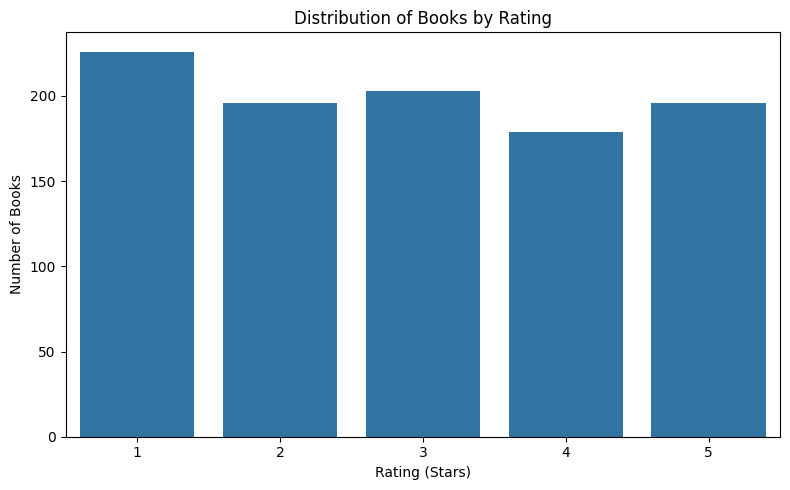

In [ ]:
# Visualize the distribution of books by rating

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_summary,
    x="Rating_Stars",
    y="Book_Count"
)

plt.title("Distribution of Books by Rating")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Price Band Analysis

In [ ]:
# Analyze the distribution of books across price bands

price_band_summary = (
    df_eda["price_band"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .reset_index()
)

price_band_summary.columns = ["Price_Band", "Book_Count"]

display(price_band_summary)

,Price_Band,Book_Count
0,Low,196
1,Medium,401
2,High,403


Price Band Bar Chart

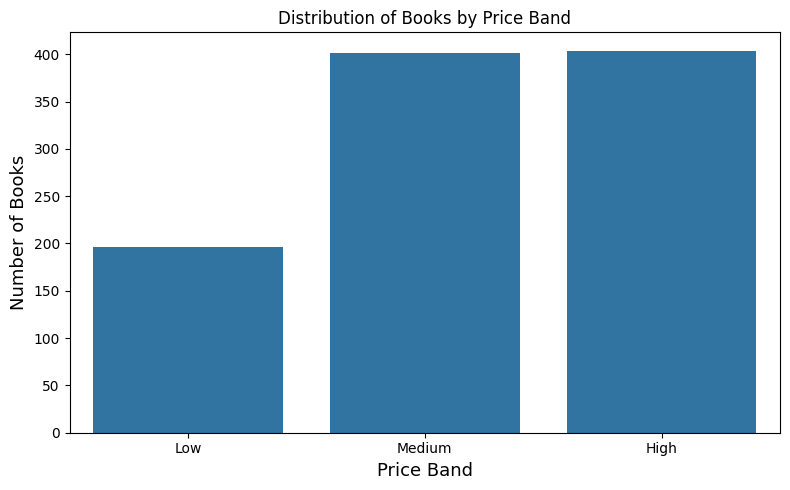

In [ ]:
# Visualize the distribution of books across price bands

plt.figure(figsize=(8, 5))

sns.barplot(
    data=price_band_summary,
    x="Price_Band",
    y="Book_Count"
)

plt.title("Distribution of Books by Price Band")
plt.xlabel("Price Band", fontsize=13)
plt.ylabel("Number of Books", fontsize=13)
plt.tight_layout()
plt.show()

Rating vs Average Price

In [ ]:
# Calculate average price for each rating level

rating_price_analysis = (
    df_eda.groupby("rating_stars", as_index=False)["price_gbp"]
    .mean()
    .rename(columns={"price_gbp": "average_price"})
)

display(rating_price_analysis.round(2))


,rating_stars,average_price
0,1,34.56
1,2,34.81
2,3,34.69
3,4,36.09
4,5,35.37


Rating vs Average Price Line Chart

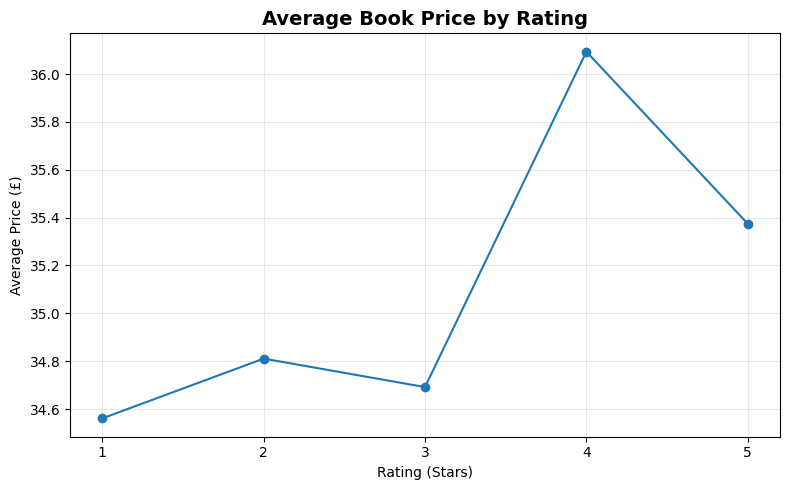

In [ ]:
# Visualize the relationship between rating and average price

plt.figure(figsize=(8, 5))

plt.plot(
    rating_price_analysis["rating_stars"],
    rating_price_analysis["average_price"],
    marker="o"
)


plt.title("Average Book Price by Rating", fontsize=14, fontweight="bold")
plt.xlabel("Rating (Stars)")
plt.ylabel("Average Price (£)")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Price Distribution

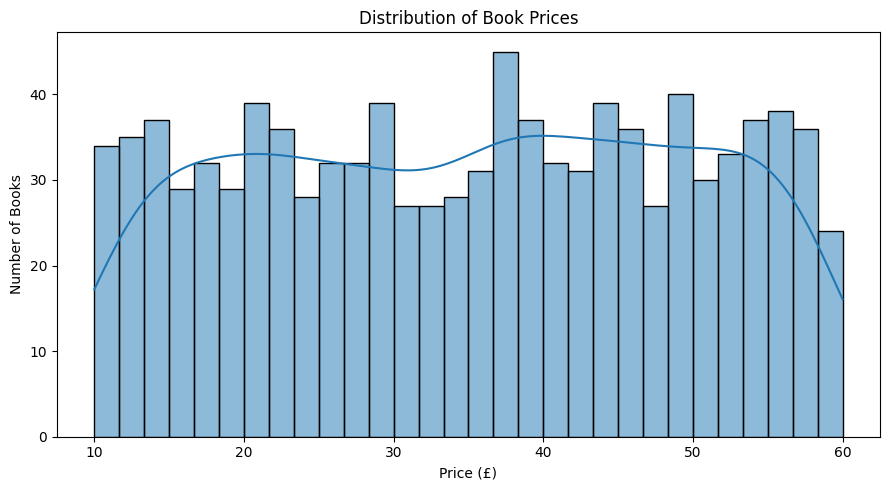

In [ ]:
# Visualize the distribution of book prices

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_eda,
    x="price_gbp",
    bins=30,
    kde=True
)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Boxplot for Price Outliers

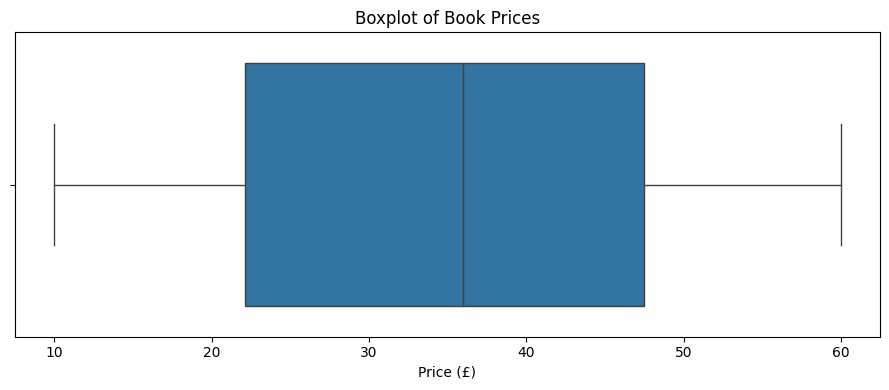

In [ ]:
# Identify potential price outliers using a boxplot

plt.figure(figsize=(9, 4))

sns.boxplot(
    x=df_eda["price_gbp"]
)

plt.title("Boxplot of Book Prices")
plt.xlabel("Price (£)")
plt.tight_layout()
plt.show()

Price Outlier Identification Using IQR

In [ ]:
# Identify potential price outliers using the IQR method

Q1 = df_eda["price_gbp"].quantile(0.25)
Q3 = df_eda["price_gbp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df_eda[
    (df_eda["price_gbp"] < lower_bound) |
    (df_eda["price_gbp"] > upper_bound)
]

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Lower Bound: £{lower_bound:.2f}")
print(f"Upper Bound: £{upper_bound:.2f}")
print(f"Potential price outliers: {len(price_outliers)}")

Q1: £22.11
Q3: £47.46
IQR: £25.35
Lower Bound: £-15.92
Upper Bound: £85.48
Potential price outliers: 0


Price vs Rating Scatter Plot

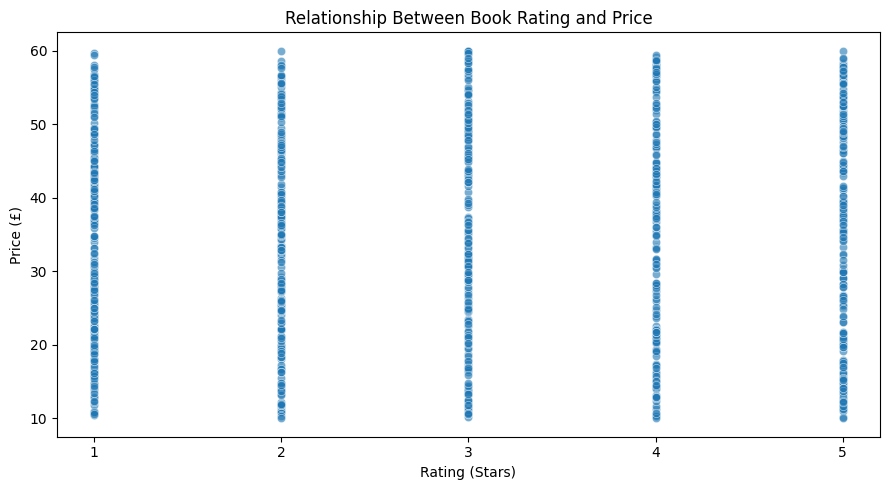

In [ ]:
# Visualize the relationship between price and rating

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_eda,
    x="rating_stars",
    y="price_gbp",
    alpha=0.6
)

plt.title("Relationship Between Book Rating and Price")
plt.xlabel("Rating (Stars)")
plt.ylabel("Price (£)")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

Correlation Analysis

In [ ]:
df_eda

,title,price_gbp,rating_stars,stock_status,product_url,rating_percentage,price_band,in_stock_flag
0,A Light in the Attic,51.77,3,In Stock,https://books.toscrape.com/a-light-in-the-atti...,60.0,High,1
1,Tipping the Velvet,53.74,1,In Stock,https://books.toscrape.com/tipping-the-velvet_...,20.0,High,1
2,Soumission,50.10,1,In Stock,https://books.toscrape.com/soumission_998/inde...,20.0,High,1
3,Sharp Objects,47.82,4,In Stock,https://books.toscrape.com/sharp-objects_997/i...,80.0,High,1
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,https://books.toscrape.com/sapiens-a-brief-his...,100.0,High,1
...,...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,1,In Stock,https://books.toscrape.com/alice-in-wonderland...,20.0,High,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,4,In Stock,https://books.toscrape.com/ajin-demi-human-vol...,80.0,High,1
997,A Spy's Devotion (The Regency Spies of London #1),16.97,5,In Stock,https://books.toscrape.com/a-spys-devotion-the...,100.0,Low,1
998,1st to Die (Women's Murder Club #1),53.98,1,In Stock,https://books.toscrape.com/1st-to-die-womens-m...,20.0,High,1


In [ ]:
# Calculate correlations among numerical variables

correlation_columns = [
    "price_gbp",
    "rating_stars"
]

correlation_matrix = df_eda[correlation_columns].corr()

display(correlation_matrix.round(2))

,price_gbp,rating_stars
price_gbp,1.00,0.03
rating_stars,0.03,1.00


Correlation Heatmap

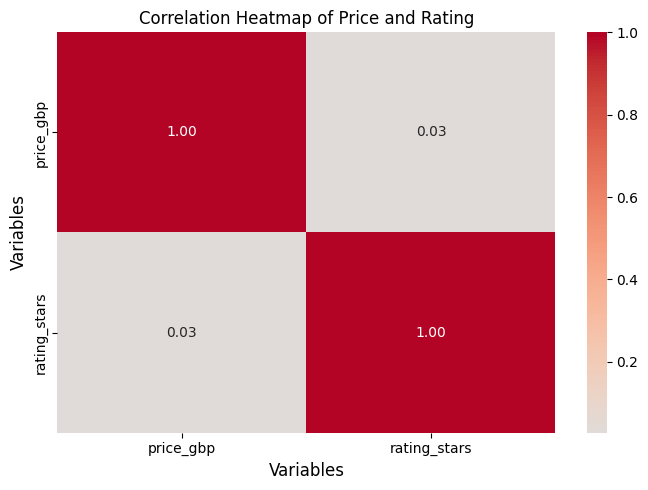

In [ ]:
# Visualize the correlation matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Price and Rating")
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.tight_layout()
plt.show()

Stock Availability Analysis

In [ ]:
# Analyze stock availability

stock_summary = (
    df_eda["stock_status"]
    .value_counts()
    .reset_index()
)

stock_summary.columns = ["Stock_Status", "Book_Count"]

display(stock_summary)

,Stock_Status,Book_Count
0,In Stock,1000


Stock Availability Visualization

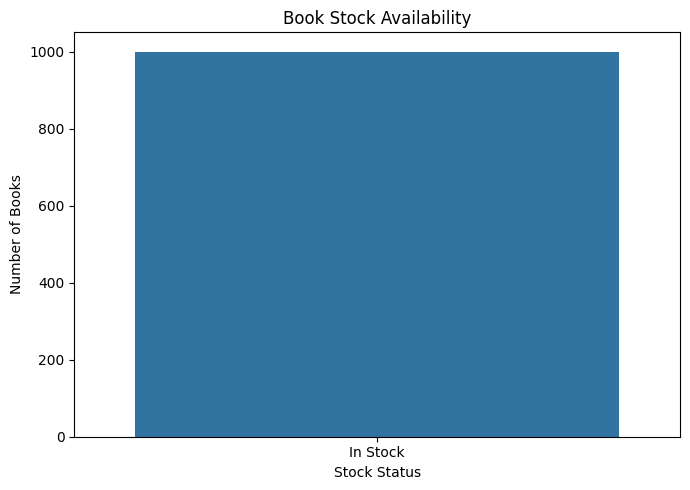

In [ ]:
# Visualize stock availability

plt.figure(figsize=(7, 5))

sns.barplot(
    data=stock_summary,
    x="Stock_Status",
    y="Book_Count"
)

plt.title("Book Stock Availability")
plt.xlabel("Stock Status")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Key EDA Summary Table

In [ ]:
# Create a consolidated EDA summary

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Books",
        "Average Price",
        "Median Price",
        "Minimum Price",
        "Maximum Price",
        "Average Rating",
        "Potential Price Outliers"
    ],
    "Value": [
        len(df_eda),
        round(df_eda["price_gbp"].mean(), 2),
        round(df_eda["price_gbp"].median(), 2),
        round(df_eda["price_gbp"].min(), 2),
        round(df_eda["price_gbp"].max(), 2),
        round(df_eda["rating_stars"].mean(), 2),
        len(price_outliers)
    ]
})

display(eda_summary)

,Metric,Value
0,Total Books,1000.00
1,Average Price,35.07
2,Median Price,35.98
3,Minimum Price,10.00
4,Maximum Price,59.99
5,Average Rating,2.92
6,Potential Price Outliers,0.00


# Key Findings and Business Insights

## Key Findings

1. The dataset contains 1,000 books collected from the Books to Scrape website.

2. The average book price is approximately £35.07, while the median price is approximately £35.98.

3. Book prices range from £10.00 to £59.99, indicating a relatively broad price range within the dataset.

4. The average book rating is approximately 2.92 stars, indicating that the overall rating level is below 3 stars.

5. The correlation between book price and rating is approximately 0.03, indicating an almost negligible linear relationship between these variables.

6. The IQR-based analysis identified no potential price outliers in the dataset.

7. All 1,000 books are currently listed as in stock. Therefore, stock availability does not provide meaningful variation for comparative analysis in this dataset.

## Business Insights

- Book price does not appear to be strongly associated with customer rating in this dataset.
- The majority of books are concentrated within the observed price range, with no extreme price observations detected using the IQR method.
- Rating distribution can help identify the overall quality perception of the books available on the website.
- Price-band analysis can support pricing segmentation and comparison of books across different price levels.
- Since all books are currently in stock, inventory availability cannot be used to distinguish products in the current dataset.

# Conclusion

The exploratory data analysis provided an overall understanding of book pricing, ratings, stock availability, and relationships among the available numerical variables. The analysis identified key distribution patterns, examined potential price outliers, and evaluated the relationship between book price and rating.

The findings from this phase will be used as a foundation for the subsequent machine learning and business intelligence stages of the capstone project.

# Capstone Project - Phase 4: Machine Learning Model Building

**Objective:** Build and evaluate a machine learning classification model to predict book ratings (`rating_stars`) based on product price (`price_gbp`).

**Target Variable:** `rating_stars` (Multi-class Classification: 1, 2, 3, 4, 5)
**Predictor Feature:** `price_gbp`

Import Machine Learning Libraries

In [ ]:
# Import libraries required for machine learning

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


Prepare Features and Target

In [ ]:
# Select predictor feature (X) and target variable (y) from existing df_eda
X = df_eda[["price_gbp"]]
y = df_eda["rating_stars"]

print("Features and target variable prepared successfully.")
print("\nPredictor Feature(s):", X.columns.tolist())
print("Target Variable:", y.name)

Features and target variable prepared successfully.

Predictor Feature(s): ['price_gbp']
Target Variable: rating_stars


Target Class Distribution

In [ ]:
# Examine the distribution of the target variable

target_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("Rating_Stars")
    .reset_index(name="Book_Count")
)


# OR

# # Examine target class distribution
# target_distribution = y.value_counts().sort_index().reset_index()
# target_distribution.columns = ["Rating_Stars", "Book_Count"]
# display(target_distribution)


display(target_distribution)

,Rating_Stars,Book_Count
0,1,226
1,2,196
2,3,203
3,4,179
4,5,196


Train-Test Split

In [ ]:
# Split dataset (80% Train, 20% Test) with class stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test split completed successfully.")
print(f"Training Records: {len(X_train)}")
print(f"Testing Records : {len(X_test)}")

Train-Test split completed successfully.
Training Records: 800
Testing Records : 200


Train Classification Model

In [ ]:
# Initialize and train the Decision Tree classification model

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree classification model trained successfully.")

Decision Tree classification model trained successfully.


Generate Predictions

In [ ]:
# Generate predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred)}")

Predictions generated successfully.
Number of predictions: 200


Model Accuracy

In [ ]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 18.50%


Classification Report

In [ ]:
# Generate a detailed classification report

print("Classification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.21      0.33      0.26        45
           2       0.14      0.21      0.16        39
           3       0.24      0.17      0.20        41
           4       0.33      0.08      0.13        36
           5       0.12      0.10      0.11        39

    accuracy                           0.18       200
   macro avg       0.21      0.18      0.17       200
weighted avg       0.21      0.18      0.18       200



Confusion Matrix

In [ ]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print("-" * 60)

print(cm)

Confusion Matrix
------------------------------------------------------------
[[15 17  5  1  7]
 [16  8  4  2  9]
 [14 12  7  1  7]
 [12 10  6  3  5]
 [14 12  7  2  4]]


Visualize Confusion Matrix

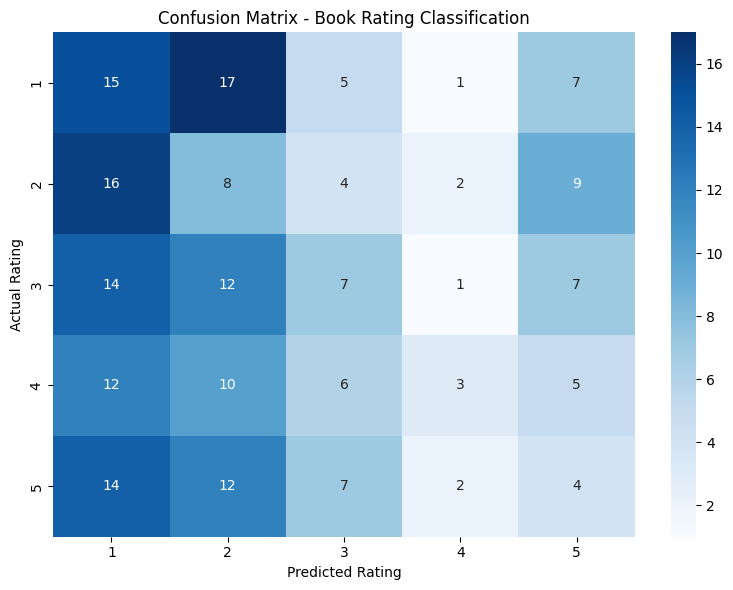

In [ ]:
# Visualize the confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

plt.title("Confusion Matrix - Book Rating Classification")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.tight_layout()
plt.show()

Feature Importance

In [ ]:
# Examine feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

display(feature_importance)

,Feature,Importance
0,price_gbp,1.0


Sample Predictions

In [ ]:
# Display sample actual and predicted ratings

prediction_results = pd.DataFrame({
    "Actual_Rating": y_test.values,
    "Predicted_Rating": y_pred
})

display(prediction_results.head(10))

,Actual_Rating,Predicted_Rating
0,1,2
1,5,2
2,2,1
3,3,1
4,5,1
5,4,1
6,4,4
7,1,5
8,2,5
9,1,2


Model Performance Summary

In [ ]:
# Create a model performance summary

model_performance = pd.DataFrame({
    "Metric": [
        "Model",
        "Problem Type",
        "Training Records",
        "Testing Records",
        "Accuracy"
    ],
    "Value": [
        "Decision Tree Classifier",
        "Multi-class Classification",
        len(X_train),
        len(X_test),
        f"{accuracy:.2%}"
    ]
})

display(model_performance)

,Metric,Value
0,Model,Decision Tree Classifier
1,Problem Type,Multi-class Classification
2,Training Records,800
3,Testing Records,200
4,Accuracy,18.50%


Baseline Benchmark

In [ ]:
# Establish a simple majority-class baseline for comparison

from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_predictions
)

print(f"Majority Class Baseline Accuracy: {dummy_accuracy:.2%}")

Majority Class Baseline Accuracy: 22.50%


Compare All Models

In [ ]:
# Compare baseline and decision tree models (Classification)
final_model_comparison = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "Decision Tree Classifier"
    ],
    "Features": [
        "No predictive features",
        "Price"
    ],
    "Accuracy": [
        dummy_accuracy,
        accuracy
    ]
})

final_model_comparison["Accuracy"] = (
    final_model_comparison["Accuracy"] * 100
).round(2)

display(final_model_comparison)

,Model,Features,Accuracy
0,Majority Class Baseline,No predictive features,22.5
1,Decision Tree Classifier,Price,18.5


#Regression Experiment (Predicting Book Price)

To explore whether textual features (book titles) provide predictive capability for numerical targets, a Regression task was conducted to predict book price (`price_gbp`).

* **Target Variable:** `price_gbp`
* **Predictors:** Book Title (TF-IDF Features) + Rating Stars

Model Training

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import numpy as np
import pandas as pd

# 1. Target and Predictors Selection
X_reg_text = df_eda["title"].fillna("").astype(str)
X_reg_num = df_eda[["rating_stars"]]
y_reg = df_eda["price_gbp"]

# 2. Train-Test Split (80% Train, 20% Test)
# Target (y_reg) ko sath me pass karne par 6 outputs properly unpack honge
X_text_tr, X_text_te, X_num_tr, X_num_te, y_reg_train, y_reg_test = train_test_split(
    X_reg_text, X_reg_num, y_reg, test_size=0.20, random_state=42
)

# 3. Mean Baseline Regressor
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_num_tr, y_reg_train)
y_pred_dummy = dummy_reg.predict(X_num_te)

# 4. TF-IDF Text Feature Extraction
tfidf_reg = TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 2))
X_text_tr_tfidf = tfidf_reg.fit_transform(X_text_tr)
X_text_te_tfidf = tfidf_reg.transform(X_text_te)

# Combine Text Features with Numerical Rating Stars
X_tr_reg_combined = hstack([X_text_tr_tfidf, X_num_tr.values])
X_te_reg_combined = hstack([X_text_te_tfidf, X_num_te.values])

# 5. Train Ridge Regression Model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_tr_reg_combined, y_reg_train)
y_pred_ridge = ridge_model.predict(X_te_reg_combined)

print("Regression Models Trained Successfully!")

Regression Models Trained Successfully!


Evaluation Summary Table

In [ ]:
# Function to calculate MAE, RMSE, and R2 metrics
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 2), round(rmse, 2), round(r2, 4)

mae_base, rmse_base, r2_base = evaluate_regression(y_reg_test, y_pred_dummy)
mae_ridge, rmse_ridge, r2_ridge = evaluate_regression(y_reg_test, y_pred_ridge)

# Summary DataFrame
final_summary = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "Decision Tree Classifier",
        "Mean Price Baseline Regressor",
        "TF-IDF + Ridge Regressor"
    ],
    "Problem Type": [
        "Classification (Rating Stars)",
        "Classification (Rating Stars)",
        "Regression (Price GBP)",
        "Regression (Price GBP)"
    ],
    "Performance Metrics": [
        "Accuracy: 22.50%",
        "Accuracy: 18.50%",
        f"MAE: £{mae_base} | RMSE: £{rmse_base} | R²: {r2_base}",
        f"MAE: £{mae_ridge} | RMSE: £{rmse_ridge} | R²: {r2_ridge}"
    ]
})

display(final_summary)

,Model,Problem Type,Performance Metrics
0,Majority Class Baseline,Classification (Rating Stars),Accuracy: 22.50%
1,Decision Tree Classifier,Classification (Rating Stars),Accuracy: 18.50%
2,Mean Price Baseline Regressor,Regression (Price GBP),MAE: £12.66 | RMSE: £14.53 | R²: -0.0051
3,TF-IDF + Ridge Regressor,Regression (Price GBP),MAE: £14.18 | RMSE: £16.23 | R²: -0.2544


## Final Machine Learning Insights & Conclusion

1. **Classification Evaluation:**
   Attempting to classify book ratings based on price yielded an accuracy of **18.50%**, failing to outperform the **22.50% Majority Class Baseline**.

2. **Regression Evaluation:**
   Predicting book prices using TF-IDF title features and ratings resulted in an MAE of **£14.18** and an $R^2$ of **-0.2544**, which also failed to beat the **Mean Price Baseline** (MAE: £12.66).

3. **Key Finding:**
   Neither book titles nor star ratings hold strong linear or textual predictive power for book pricing in this dataset. Simple metadata features are insufficient for price and rating estimation without richer context (such as genre categories, page counts, or detailed customer reviews).